# Range evaluation

**Part A — Preflop latent hand posteriors** over 169 classes (prior-only vs population vs player-tilted E-step).

**Part B — `filter_sessions_range_history.csv`** combo-range export (enrichment + calibration columns).

Splits: `sessions_theta` / `sessions_filter`. Code: `utils.eval.range_evaluation_helpers`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

def _find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for x in (p, *p.parents):
        if (x / "runners" / "common.py").is_file():
            return x
    raise FileNotFoundError("Run from inside the repo (runners/common.py not found).")

REPO = _find_repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import json

import matplotlib.pyplot as plt
import numpy as np

from utils.eval.range_evaluation_helpers import (
    em_and_online_hand_refs,
    compute_all_posterior_results,
    true_hand_nll,
    ranks_from_results,
    default_observer_map,
)
from utils.eval.player_thetas_evaluation_helpers import load_global_betas, load_player_thetas

priors = json.loads((REPO / "artifacts" / "global_priors.json").read_text())
BETA_PRE, _, _ = load_global_betas(priors)
thetas_payload = json.loads((REPO / "artifacts" / "player_thetas.json").read_text())
PLAYERS, _, THETA_PRE = load_player_thetas(thetas_payload)
OBSERVER_OF = default_observer_map(PLAYERS)
print("observer map:", OBSERVER_OF)

observer map: {'MrBlue': 'Bill', 'Bill': 'Pluribus', 'Pluribus': 'MrBlue'}


In [2]:
em_refs, online_refs = em_and_online_hand_refs(REPO)
print("em hands", len(em_refs), "online hands", len(online_refs))

em hands 541 online hands 1015


In [3]:
RESULTS = compute_all_posterior_results(
    PLAYERS,
    OBSERVER_OF,
    beta_pre=BETA_PRE,
    theta_pre=THETA_PRE,
    em_refs=em_refs,
    online_refs=online_refs,
)
print("settings", len(RESULTS))

settings 18


In [4]:
print(f"{'player':<10} {'split':<7} {'predictor':<11} {'NLL':>8}")
for player in PLAYERS:
    for split in ("em", "online"):
        for predictor in ("prior_only", "population", "player"):
            v = true_hand_nll(RESULTS[(player, split, predictor)])
            print(f"{player:<10} {split:<7} {predictor:<11} {v:>8.4f}")

player     split   predictor        NLL
MrBlue     em      prior_only    5.0137
MrBlue     em      population    4.8933
MrBlue     em      player        4.8944
MrBlue     online  prior_only    5.0193
MrBlue     online  population    4.9114
MrBlue     online  player        4.9137
Bill       em      prior_only    5.0122
Bill       em      population    4.8737
Bill       em      player        4.8747
Bill       online  prior_only    4.9864
Bill       online  population    4.8608
Bill       online  player        4.8607
Pluribus   em      prior_only    4.9679
Pluribus   em      population    4.8535
Pluribus   em      player        4.8536
Pluribus   online  prior_only    4.9851
Pluribus   online  population    4.8687
Pluribus   online  player        4.8687


In [5]:
from utils.strength.preflop import all_169_classes
ALL_169 = all_169_classes()
IX = {h: i for i, h in enumerate(ALL_169)}
RANKS = {k: ranks_from_results(res, all_169=ALL_169, index_of=IX) for k, res in RESULTS.items()}
print(f"{'player':<10} {'split':<7} {'predictor':<11} {'mean_rank':>10} {'median_rank':>12}")
for key, r in RANKS.items():
    if r.size == 0:
        continue
    p, sp, pred = key
    print(f"{p:<10} {sp:<7} {pred:<11} {r.mean():>10.2f} {np.median(r):>12.1f}")

player     split   predictor    mean_rank  median_rank
MrBlue     em      prior_only       63.14         53.0
MrBlue     em      population       54.04         44.0
MrBlue     em      player           53.68         43.0
MrBlue     online  prior_only       63.73         54.0
MrBlue     online  population       54.80         46.0
MrBlue     online  player           54.76         45.0
Bill       em      prior_only       64.43         55.0
Bill       em      population       52.21         42.0
Bill       em      player           52.32         42.0
Bill       online  prior_only       60.13         47.0
Bill       online  population       51.03         39.0
Bill       online  player           51.08         39.0
Pluribus   em      prior_only       57.98         46.5
Pluribus   em      population       50.62         40.0
Pluribus   em      player           50.63         40.0
Pluribus   online  prior_only       61.78         53.0
Pluribus   online  population       51.60         41.0
Pluribus  

In [6]:
KS = (1, 5, 10, 20, 50)
header = ["player", "split", "predictor"] + [f"top-{k}" for k in KS]
print("  ".join(f"{h:<10}" for h in header))
for (p, sp, pred), r in RANKS.items():
    if r.size == 0:
        continue
    cells = [p, sp, pred] + [f"{(r <= k).mean():.3f}" for k in KS]
    print("  ".join(f"{c:<10}" for c in cells))

player      split       predictor   top-1       top-5       top-10      top-20      top-50    
MrBlue      em          prior_only  0.008       0.043       0.098       0.195       0.457     
MrBlue      em          population  0.015       0.072       0.149       0.270       0.560     
MrBlue      em          player      0.017       0.068       0.151       0.289       0.567     
MrBlue      online      prior_only  0.011       0.047       0.088       0.175       0.463     
MrBlue      online      population  0.021       0.082       0.149       0.278       0.524     
MrBlue      online      player      0.021       0.083       0.150       0.278       0.529     
Bill        em          prior_only  0.009       0.045       0.103       0.174       0.453     
Bill        em          population  0.017       0.090       0.170       0.308       0.554     
Bill        em          player      0.017       0.090       0.170       0.299       0.552     
Bill        online      prior_only  0.013       0.

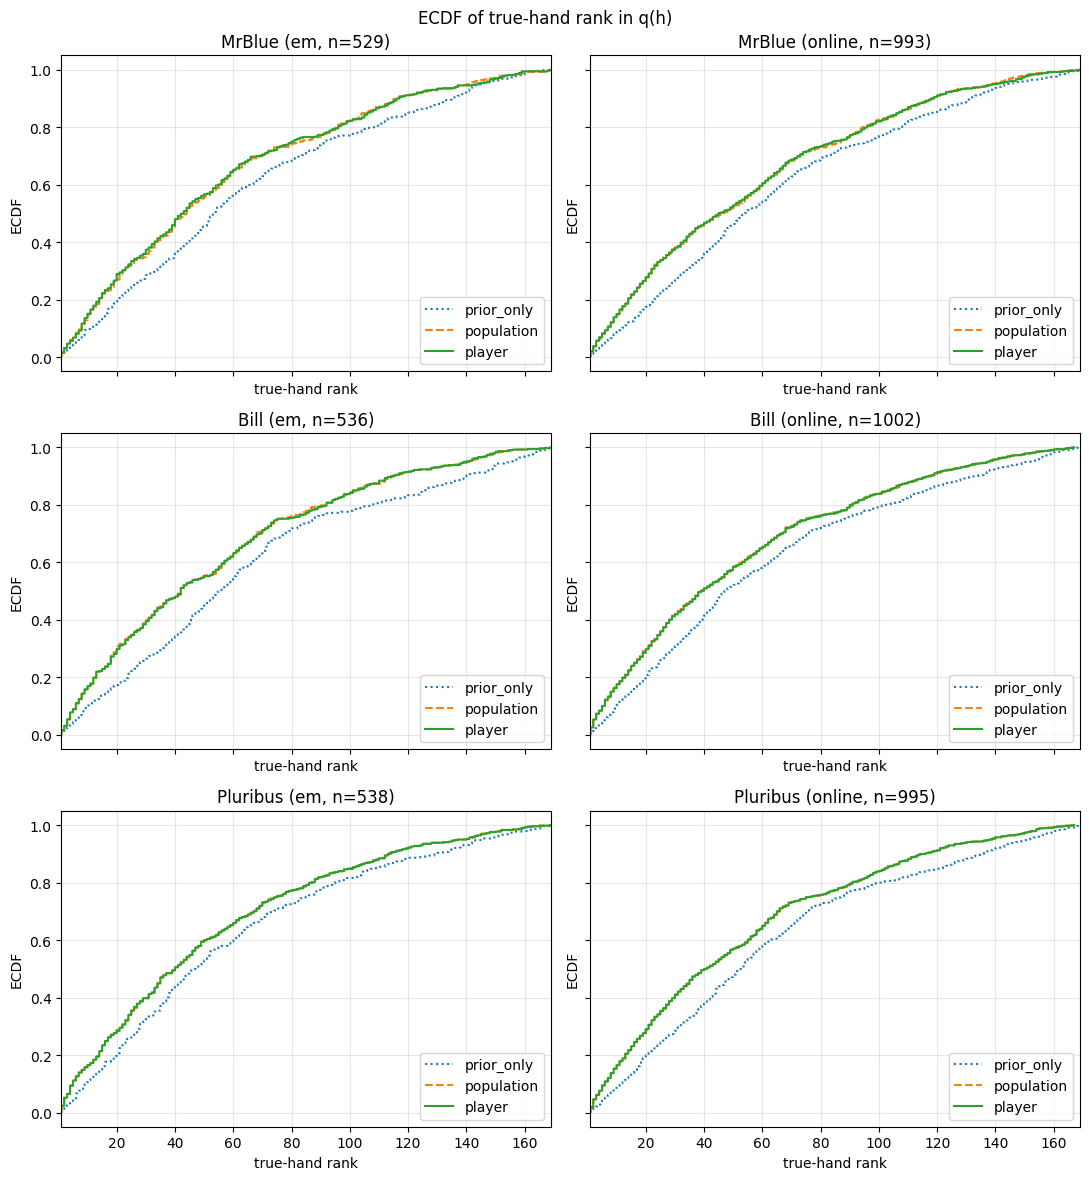

In [7]:
def ecdf(arr):
    x = np.sort(arr)
    y = np.arange(1, x.size + 1) / x.size
    return x, y

fig, axes = plt.subplots(len(PLAYERS), 2, figsize=(11, 4 * len(PLAYERS)), sharex=True, sharey=True)
if len(PLAYERS) == 1:
    axes = np.array([axes])
for i, player in enumerate(PLAYERS):
    for j, split in enumerate(("em", "online")):
        ax = axes[i, j]
        for predictor, ls in (("prior_only", ":"), ("population", "--"), ("player", "-")):
            r = RANKS[(player, split, predictor)]
            if r.size == 0:
                continue
            x, y = ecdf(r)
            ax.step(x, y, where="post", label=predictor, linestyle=ls)
        ax.set_title(f"{player} ({split}, n={RANKS[(player, split, 'player')].size})")
        ax.set_xlabel("true-hand rank")
        ax.set_ylabel("ECDF")
        ax.set_xlim(1, 169)
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)
fig.suptitle("ECDF of true-hand rank in q(h)")
fig.tight_layout()
plt.show()

## Part B — filter-session combo-range CSV

Requires `artifacts/filter_sessions_range_history.csv`. Set `MAX_ROWS = None` for a full run.

In [27]:
from IPython.display import display
from utils.eval.range_evaluation_helpers import run_filter_sessions_range_evaluation

CSV_PATH = REPO / "artifacts" / "filter_sessions_range_history.csv"
STRENGTH_MC_SAMPLES = 100
RNG_SEED = 0
MAX_ROWS = 1000

if not CSV_PATH.is_file():
    print(f"Skip Part B: missing {CSV_PATH}")
else:
    out = run_filter_sessions_range_evaluation(
        REPO,
        csv_path=CSV_PATH,
        strength_mc_samples=STRENGTH_MC_SAMPLES,
        rng_seed=RNG_SEED,
        max_rows=MAX_ROWS,
        verbose=True,
    )
    print("rows:", out["n_rows"], "combo prob cols:", out["n_combo_prob_cols"])
    print("streets:", out["streets"])
    display(out["df_calib"].head())

[eval] enrich_online_range_dataframe: 1000 rows | pluribus_root=/Users/kevinliu/Desktop/bayesian poker/pluribus
[eval] enrich … row 1/1000
[eval] enrich … row 100/1000
[eval] enrich … row 200/1000
[eval] enrich … row 300/1000
[eval] enrich … row 400/1000
[eval] enrich … row 500/1000
[eval] enrich … row 600/1000
[eval] enrich … row 700/1000
[eval] enrich … row 800/1000
[eval] enrich … row 900/1000
[eval] enrich … row 1000/1000
[eval] enrich_online_range_dataframe: done (70 unique session/hand hands cached)
[eval] add_calibration_columns: 1000 rows | strength_mc_samples=100
[eval] calibration … row 1/1000
[eval] calibration … row 50/1000
[eval] calibration … row 100/1000
[eval] calibration … row 150/1000
[eval] calibration … row 200/1000
[eval] calibration … row 250/1000
[eval] calibration … row 300/1000
[eval] calibration … row 350/1000
[eval] calibration … row 400/1000
[eval] calibration … row 450/1000
[eval] calibration … row 500/1000
[eval] calibration … row 550/1000
[eval] calibrati

,session,hand_number,street,observer,target,3s2s,4s2s,5s2s,6s2s,7s2s,...,made_strength_pct__AsKc,made_strength_pct__AhKc,made_strength_pct__AdKc,made_strength_pct__AcKc,made_strength_pct__AhAs,made_strength_pct__AdAs,made_strength_pct__AcAs,made_strength_pct__AdAh,made_strength_pct__AcAh,made_strength_pct__AcAd
0,40b,121,pre-flop,MrBlue,Bill,0.000828,0.000836,0.000845,0.000855,0.000862,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,40b,121,flop,MrBlue,Bill,0.000828,0.000836,0.001127,0.000855,0.000862,...,NaN,NaN,NaN,NaN,0.912581,0.912581,0.912581,0.912581,0.912581,0.912581
2,40b,121,turn,MrBlue,Bill,0.000831,0.000839,0.001130,0.000858,0.000865,...,NaN,NaN,NaN,NaN,0.956039,0.956039,0.956039,0.956039,0.956039,0.956039
3,40b,121,river,MrBlue,Bill,0.000000,0.000839,0.001130,0.000858,0.000865,...,NaN,NaN,NaN,NaN,0.955051,0.955051,0.955051,0.955051,0.955051,0.955051
4,40b,121,pre-flop,Bill,MrBlue,0.000914,0.000896,0.000877,0.000856,0.000839,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


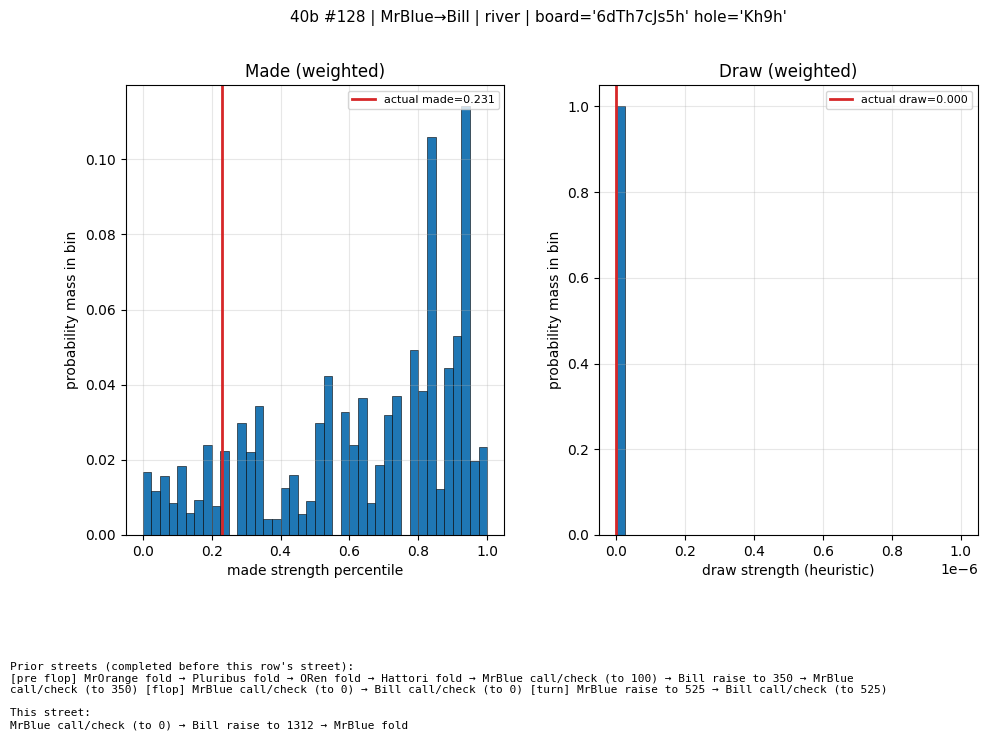

In [29]:
from utils.eval import combo_probability_columns, plot_made_distribution

_df_calib = out["df_calib"]

_combo_cols = combo_probability_columns(_df_calib)
fig, _axes = plot_made_distribution(
    _df_calib,
    session='40b',
    hand_number='128',
    observer='MrBlue',
    target='Bill',
    street='river',
    combo_cols=_combo_cols,
    pluribus_root=REPO / "pluribus",
)
plt.show()

In [38]:
_df_calib[
    (_df_calib["session"] == '40b')
    & (_df_calib["hand_number"] == 128)
    & (_df_calib["street"] == 'river')
]


,session,hand_number,street,observer,target,3s2s,4s2s,5s2s,6s2s,7s2s,...,made_strength_pct__AsKc,made_strength_pct__AhKc,made_strength_pct__AdKc,made_strength_pct__AcKc,made_strength_pct__AhAs,made_strength_pct__AdAs,made_strength_pct__AcAs,made_strength_pct__AdAh,made_strength_pct__AcAh,made_strength_pct__AcAd
141,40b,128,river,MrBlue,Bill,0.000559,0.000546,0.000311,0.000777,0.000872,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
145,40b,128,river,Bill,MrBlue,0.001547,0.001428,0.001698,0.001193,0.001109,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
149,40b,128,river,MrBlue,Pluribus,0.000825,0.000832,0.001120,0.001132,0.001140,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
153,40b,128,river,Pluribus,MrBlue,0.001548,0.001428,0.001698,0.001193,0.001109,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
157,40b,128,river,Bill,Pluribus,0.000825,0.000832,0.001120,0.001132,0.001140,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
161,40b,128,river,Pluribus,Bill,0.000559,0.000546,0.000311,0.000776,0.000872,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949


In [30]:
combo_cols = [col for col in _df_calib.iloc[0].index if len(col) == 4]

In [40]:
def top_k_hands(session, hand_number, street, observer, target, k=10):
    row = _df_calib[
        (_df_calib["session"] == session)
        & (_df_calib["hand_number"] == hand_number)
        & (_df_calib["street"] == street)
        & (_df_calib["observer"] == observer)
        & (_df_calib["target"] == target)
    ].iloc[0]

    sorted_cols = sorted(combo_cols, key=lambda col: row[col], reverse=True)
    return {col: row[col].item() for col in sorted_cols[:k]}


top_k_hands(session='40b', hand_number=128, street='river', observer='MrBlue', target='Bill', k=10)

{'Jh7h': 0.0035597176697895,
 'TcTs': 0.0035383593643522,
 'TcTd': 0.0035383192863614,
 'TdTs': 0.0035380537377513,
 'Jh6h': 0.0035316369818184,
 'Jd7d': 0.0034794803952731,
 'Jc6c': 0.0034530666170222,
 'JdTd': 0.0033854800343064,
 'JcTc': 0.0033843062338212,
 'JcJd': 0.0032085155052387}